In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
# from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve,auc, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
import joblib
import optuna
# ==========================================================
# 1. LOAD DATA
# ==========================================================

df = pd.read_csv("flight_dataset_v2Copy.csv", parse_dates=[
    "scheduled_departure_time", 
    "scheduled_arrival_time", "dep_date_only"
])

# ==========================================================
# 2. DROP UNNECESSARY / LEAKAGE COLUMNS
# ==========================================================

drop_cols = [
    'id', 'dep_date_only','is_diverted', 'is_cancelled','delay_class_dep'
]

df = df.drop(columns=drop_cols)

# ==========================================================
# 3. TIME FEATURES
# ==========================================================

for col in ["scheduled_departure_time", "scheduled_arrival_time"]:
    df[col] = df[col].dt.hour * 60 + df[col].dt.minute
    df[col] = df[col].fillna(0)

# ==========================================================
# 4. CATEGORICAL ENCODING
# ==========================================================

categorical_cols = [
    "airline", "aircraft_type", "origin_code", "destination_code",
    "scheduled_departure_day_of_week", "scheduled_arrival_day_of_week","route",
]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# ==========================================================
# 5. TARGET & FEATURES
# ==========================================================

target_col = "binary_delay_dep"
X = df.drop(columns=[target_col])
y = df[target_col]

# ==========================================================
# 6. TRAIN-VALID SPLIT
# ==========================================================

# Stratified split preserves class balance
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==========================================================
# 7. HANDLE CLASS IMBALANCE
# ==========================================================

counts = y_train.value_counts()
scale_pos_weight = counts[0] / counts[1]

# ==========================================================
# 8. OPTUNA HYPERPARAMETER TUNING
# ==========================================================

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 128),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.7, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.7, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 5.0),
        'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 5.0),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42,
        'verbose': -1
    }

    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
    val_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=3000,
        valid_sets=[val_data],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(0)
        ]
    )

    trial.set_user_attr("best_iteration", model.best_iteration)
    preds = model.predict(X_valid, num_iteration=model.best_iteration)
    return roc_auc_score(y_valid, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

best_params = study.best_params
best_iteration = study.best_trial.user_attrs["best_iteration"]
print("Best Params:", best_params)
print("Best Iteration:", best_iteration)

# ==========================================================
# 9. TRAIN FINAL MODEL ON FULL DATA
# ==========================================================

best_params.update({
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,
    'seed': 42,
    'verbose': -1
})

full_data = lgb.Dataset(X, label=y, categorical_feature=categorical_cols)

final_model = lgb.train(
    best_params,
    full_data,
    num_boost_round=best_iteration
)

val_probs = final_model.predict(X_valid)
val_preds = (val_probs >= 0.5).astype(int)


print("ROC-AUC:", roc_auc_score(y_valid, val_probs))
print("Accuracy:", accuracy_score(y_valid, val_preds))
print("F1 Score:", f1_score(y_valid, val_preds))
print("Precision",precision_score(y_valid, val_preds, zero_division=0))
print("Recall",recall_score(y_valid, val_preds, zero_division=0))
print("Classification Report:", classification_report(y_valid, val_preds))
print("\nFinal Evaluation:")
# ==========================================================
# 12. FEATURE IMPORTANCE
# ==========================================================

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.feature_importance(importance_type="gain")
}).sort_values(by="importance", ascending=False)

print("\nTop Features:\n", feature_importance.head(20))


[I 2026-02-26 20:16:28,500] A new study created in memory with name: no-name-ad714a80-dedf-48ab-8c3c-1c453e0457be


Training until validation scores don't improve for 100 rounds


[I 2026-02-26 20:16:31,365] Trial 0 finished with value: 0.7558151653828298 and parameters: {'learning_rate': 0.07419775341559795, 'num_leaves': 96, 'max_depth': 12, 'feature_fraction': 0.8494733350188257, 'bagging_fraction': 0.7384091836398401, 'bagging_freq': 9, 'min_child_samples': 85, 'lambda_l1': 0.25612974673264455, 'lambda_l2': 4.39901155072061}. Best is trial 0 with value: 0.7558151653828298.


Early stopping, best iteration is:
[109]	valid_0's auc: 0.755815
Training until validation scores don't improve for 100 rounds


[I 2026-02-26 20:16:32,862] Trial 1 finished with value: 0.7555178931809783 and parameters: {'learning_rate': 0.07571599617620743, 'num_leaves': 42, 'max_depth': 11, 'feature_fraction': 0.8551046777608187, 'bagging_fraction': 0.736782498759208, 'bagging_freq': 8, 'min_child_samples': 96, 'lambda_l1': 1.68132543397941, 'lambda_l2': 1.6624008722185502}. Best is trial 0 with value: 0.7558151653828298.


...

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[778]	valid_0's auc: 0.761904


[I 2026-02-26 20:18:03,018] Trial 28 finished with value: 0.7619039159394749 and parameters: {'learning_rate': 0.011979548061031395, 'num_leaves': 56, 'max_depth': 6, 'feature_fraction': 0.7066454241640976, 'bagging_fraction': 0.9573199847013674, 'bagging_freq': 1, 'min_child_samples': 41, 'lambda_l1': 4.3793396323565625, 'lambda_l2': 2.8699906917070974}. Best is trial 17 with value: 0.7637917720739414.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[185]	valid_0's auc: 0.757703


[I 2026-02-26 20:18:06,284] Trial 29 finished with value: 0.7577030215172964 and parameters: {'learning_rate': 0.02363566935426424, 'num_leaves': 94, 'max_depth': 14, 'feature_fraction': 0.742858610689436, 'bagging_fraction': 0.7481186755334793, 'bagging_freq': 4, 'min_child_samples': 55, 'lambda_l1': 0.07817503357538613, 'lambda_l2': 1.120912761458288}. Best is trial 17 with value: 0.7637917720739414.


Best Params: {'learning_rate': 0.013732068382850786, 'num_leaves': 67, 'max_depth': 6, 'feature_fraction': 0.7419880178140382, 'bagging_fraction': 0.839111183443896, 'bagging_freq': 2, 'min_child_samples': 41, 'lambda_l1': 3.099929691936766, 'lambda_l2': 2.7943878223805583}
Best Iteration: 547
ROC-AUC: 0.8617009181092066
Accuracy: 0.770374167093798
F1 Score: 0.6972972972972973
Precision 0.6201923076923077
Recall 0.7962962962962963
Classification Report:               precision    recall  f1-score   support

           0       0.88      0.76      0.82      1303
           1       0.62      0.80      0.70       648

    accuracy                           0.77      1951
   macro avg       0.75      0.78      0.76      1951
weighted avg       0.80      0.77      0.78      1951


Final Evaluation:

Top Features:
                             feature    importance
0                           airline  25535.236905
17                  scheduled_month  10586.799726
29               arr_wind_spee

In [2]:
val_probs = final_model.predict(X_valid)
val_preds = (val_probs >= 0.5).astype(int)


print("ROC-AUC:", roc_auc_score(y_valid, val_probs))
print("Accuracy:", accuracy_score(y_valid, val_preds))
print("F1 Score:", f1_score(y_valid, val_preds))
print("Precision",precision_score(y_valid, val_preds, zero_division=0))
print("Recall",recall_score(y_valid, val_preds, zero_division=0))
print("Classification Report:", classification_report(y_valid, val_preds))

ROC-AUC: 0.8617009181092066
Accuracy: 0.770374167093798
F1 Score: 0.6972972972972973
Precision 0.6201923076923077
Recall 0.7962962962962963
Classification Report:               precision    recall  f1-score   support

           0       0.88      0.76      0.82      1303
           1       0.62      0.80      0.70       648

    accuracy                           0.77      1951
   macro avg       0.75      0.78      0.76      1951
weighted avg       0.80      0.77      0.78      1951



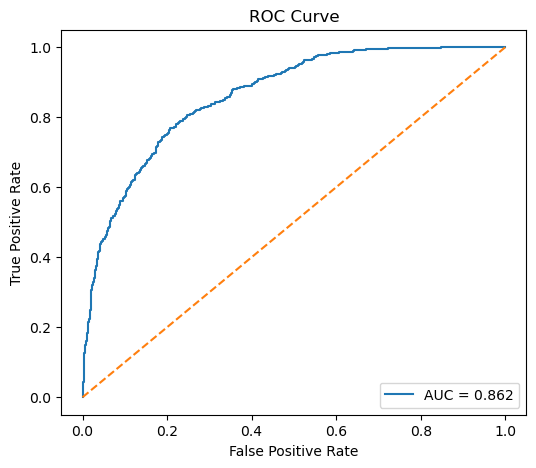

In [3]:
fpr, tpr, _ = roc_curve(y_valid, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

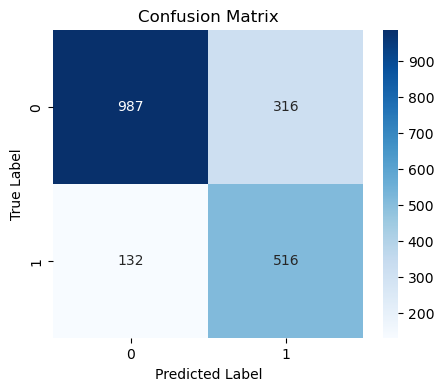

In [4]:
cm = confusion_matrix(y_valid, val_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [5]:
# Get probabilities
val_probs = final_model.predict(X_valid)

# Convert to 0/1 using threshold
val_preds = (val_probs >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_valid, val_probs))
print("Accuracy:", accuracy_score(y_valid, val_preds))
print("F1 Score:", f1_score(y_valid, val_preds))
print("Precision:", precision_score(y_valid, val_preds, zero_division=0))
print("Recall:", recall_score(y_valid, val_preds, zero_division=0))
print("Classification Report:\n", classification_report(y_valid, val_preds))

ROC-AUC: 0.8617009181092066
Accuracy: 0.770374167093798
F1 Score: 0.6972972972972973
Precision: 0.6201923076923077
Recall: 0.7962962962962963
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.76      0.82      1303
           1       0.62      0.80      0.70       648

    accuracy                           0.77      1951
   macro avg       0.75      0.78      0.76      1951
weighted avg       0.80      0.77      0.78      1951



In [6]:
# Train evaluation
train_probs = final_model.predict(X_train)
train_preds = (train_probs >= 0.5).astype(int)

print("Train Accuracy:", accuracy_score(y_train, train_preds))
print("Validation Accuracy:", accuracy_score(y_valid, val_preds))

Train Accuracy: 0.753684480328079
Validation Accuracy: 0.770374167093798


In [7]:
y.value_counts()

binary_delay_dep
0    6514
1    3240
Name: count, dtype: int64

In [8]:
# Save the trained booster to a file
final_model.save_model("flight_delay_model.txt")

In [9]:
# Gain-based importance
importance = final_model.feature_importance(importance_type='gain')
feature_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print("LGBM Feature Importance (All Features):")
print(feature_imp_df)

LGBM Feature Importance (All Features):
                              feature    importance
0                             airline  25535.236905
17                    scheduled_month  10586.799726
29                 arr_wind_speed_10m   9367.726480
24                 dep_wind_speed_10m   8829.573434
36                  airline_avg_delay   7871.027391
5            scheduled_departure_time   7015.700565
6              scheduled_arrival_time   6968.780855
37                 airline_delay_rate   6852.949849
4                       aircraft_type   6496.160147
25                    dep_cloud_cover   6378.983763
2                    destination_code   5133.342527
14    scheduled_departure_day_of_week   4840.647299
34                    route_avg_delay   4632.700755
21      scheduled_flight_duration_min   4382.431294
30                    arr_cloud_cover   4329.933405
26                     dep_visibility   3546.702225
15      scheduled_arrival_day_of_week   3309.756749
38                 aircr

In [10]:
model_columns = X.columns.tolist()  # Save this list
joblib.dump(model_columns, "model_columns.pkl")

['model_columns.pkl']

In [11]:
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [12]:
import numpy as np

thresholds = np.arange(0.3, 0.7, 0.01)
best_acc = 0
best_thresh = 0.5

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    acc = accuracy_score(y_valid, preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best Accuracy:", best_acc)


Best Threshold: 0.6100000000000003
Best Accuracy: 0.7939518195797027


In [13]:
from sklearn.metrics import precision_recall_curve

probs = final_model.predict(X_valid)
precision, recall, thresholds = precision_recall_curve(y_valid, probs)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_thresh = thresholds[f1_scores.argmax()]
print("Best threshold:", best_thresh)

val_preds = (probs >= best_thresh).astype(int)
print("Accuracy with best threshold:", accuracy_score(y_valid, val_preds))

Best threshold: 0.5244966169929186
Accuracy with best threshold: 0.7842132239876987


In [14]:
y.value_counts(normalize=True)

binary_delay_dep
0    0.667829
1    0.332171
Name: proportion, dtype: float64